```
Image
    ↓
Kernel
    ↓
Sliding Window
    ↓
Multiply
    ↓
Sum
    ↓
Feature Map
```

Hiểu rằng:
$$Convolution = \text{Pattern Matching}$$

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.convolution import Convolution2D
from src.utils import (
    load_image,
    show_image,
    plot_feature_maps
)

In [2]:
print("=" * 60)
print("CNN FROM SCRATCH")
print("02 - CONVOLUTION")
print("=" * 60)

CNN FROM SCRATCH
02 - CONVOLUTION


In [3]:
image = np.array(
[
    [1, 2, 3, 0],
    [4, 5, 6, 1],
    [7, 8, 9, 2],
    [3, 2, 1, 0]
],
dtype=np.float32
)

print(image)

[[1. 2. 3. 0.]
 [4. 5. 6. 1.]
 [7. 8. 9. 2.]
 [3. 2. 1. 0.]]


In [4]:
kernel = np.array(
[
    [1, 0],
    [0,-1]
],
dtype=np.float32
)

print(kernel)

[[ 1.  0.]
 [ 0. -1.]]


In [5]:
window = image[0:2,0:2]

print(window)

[[1. 2.]
 [4. 5.]]


In [6]:
product = window * kernel

print(product)

[[ 1.  0.]
 [ 0. -5.]]


In [7]:
value = np.sum(product)

print(value)

-4.0


In [8]:
output = np.zeros((3,3))

for i in range(3):

    for j in range(3):

        window = image[
            i:i+2,
            j:j+2
        ]

        output[i,j] = np.sum(
            window * kernel
        )

print(output)

[[-4. -4.  2.]
 [-4. -4.  4.]
 [ 5.  7.  9.]]


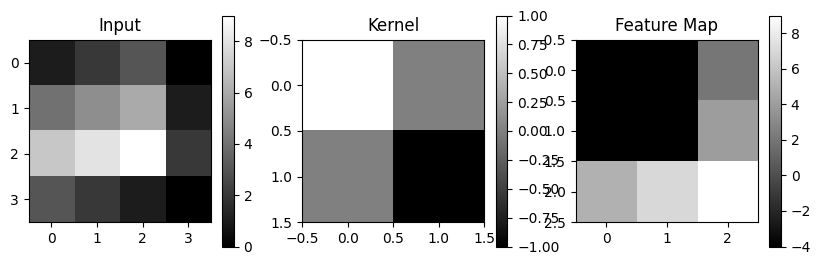

In [9]:
plt.figure(figsize=(10,3))

plt.subplot(1,3,1)
plt.imshow(image,cmap="gray")
plt.title("Input")
plt.colorbar()

plt.subplot(1,3,2)
plt.imshow(kernel,cmap="gray")
plt.title("Kernel")
plt.colorbar()

plt.subplot(1,3,3)
plt.imshow(output,cmap="gray")
plt.title("Feature Map")
plt.colorbar()

plt.show()

Part 2 - Edge Detection

In [10]:
# Cell 10 - vertical Edge filter

vertical_kernel = np.array(
[
[-1,0,1],
[-1,0,1],
[-1,0,1]
],
dtype=np.float32
)

print(vertical_kernel)

[[-1.  0.  1.]
 [-1.  0.  1.]
 [-1.  0.  1.]]


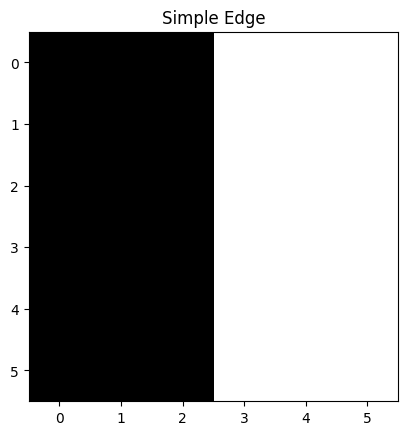

In [11]:
image = np.array(
[
[0,0,0,1,1,1],
[0,0,0,1,1,1],
[0,0,0,1,1,1],
[0,0,0,1,1,1],
[0,0,0,1,1,1],
[0,0,0,1,1,1]
],
dtype=np.float32
)

plt.imshow(
    image,
    cmap="gray"
)

plt.title(
    "Simple Edge"
)

plt.show()

In [12]:
conv = Convolution2D(
    in_channels=1,
    out_channels=1,
    kernel_size=3
)

conv.filters[:] = (
    vertical_kernel
    .reshape(1,1,3,3)
)

conv.bias[:] = 0

In [13]:
x = image[np.newaxis,:,:]

feature_map = conv.forward(x)

feature_map = feature_map[0]

print(feature_map)

[[0. 3. 3. 0.]
 [0. 3. 3. 0.]
 [0. 3. 3. 0.]
 [0. 3. 3. 0.]]


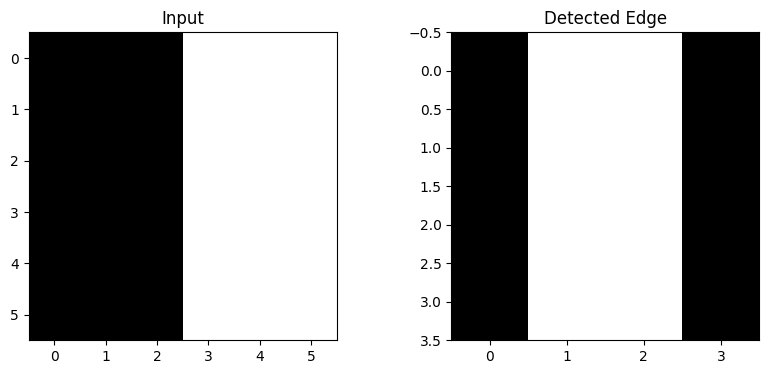

In [14]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)

plt.imshow(
    image,
    cmap="gray"
)

plt.title("Input")

plt.subplot(1,2,2)

plt.imshow(
    feature_map,
    cmap="gray"
)

plt.title(
    "Detected Edge"
)

plt.show()

Part 3 - Real Image

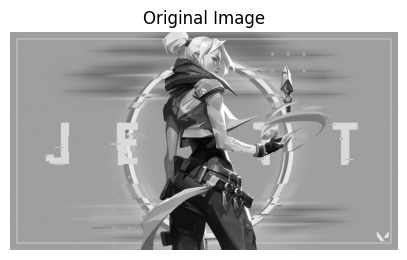

In [19]:
# Cell 15 - Load Sample Image

image = load_image(
    "../data/sample.jpg",
    grayscale=True
)

show_image(
    image,
    "Original Image"
)

In [20]:
# Cell 16 - Create Edge Detector

edge_filter = np.array(
[
[-1,-1,-1],
[ 0, 0, 0],
[ 1, 1, 1]
],
dtype=np.float32
)

In [21]:
# Cell 17 - Convolution Layer

conv = Convolution2D(
    in_channels=1,
    out_channels=1,
    kernel_size=3
)

conv.filters[:] = (
    edge_filter
    .reshape(1,1,3,3)
)

conv.bias[:] = 0

In [22]:
# Cell 18 - Forward

feature_maps = conv.forward(image)

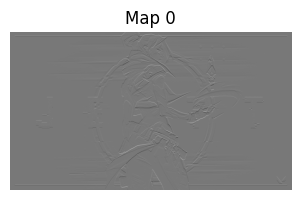

In [23]:
# Cell 19 - Show Feature Map

plot_feature_maps(
    feature_maps
)

Part 4 - Understanding filters

In [24]:
# Cell 20 -Common CNN Filters

vertical = np.array([
[-1,0,1],
[-1,0,1],
[-1,0,1]
])

horizontal = np.array([
[-1,-1,-1],
[0,0,0],
[1,1,1]
])

laplacian = np.array([
[0,1,0],
[1,-4,1],
[0,1,0]
])

print("Vertical Edge")
print(vertical)

print()

print("Horizontal Edge")
print(horizontal)

print()

print("Laplacian")
print(laplacian)

Vertical Edge
[[-1  0  1]
 [-1  0  1]
 [-1  0  1]]

Horizontal Edge
[[-1 -1 -1]
 [ 0  0  0]
 [ 1  1  1]]

Laplacian
[[ 0  1  0]
 [ 1 -4  1]
 [ 0  1  0]]
